In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import cmasher as cmr
import matplotlib.patches as ps

from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter
from sm import NeuralNet
from models import CondSM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 12,    # affects horizontal colorbar ticks
    "ytick.labelsize": 12,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

cuda


In [2]:
data_type = 'uni_1e7'

state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model = model.to(device)

print("Model loaded")

e_0 = 1.60217663e-19
time_scale = 1e21
out_scale = e_0 * time_scale

Model loaded


0.006012024048096192


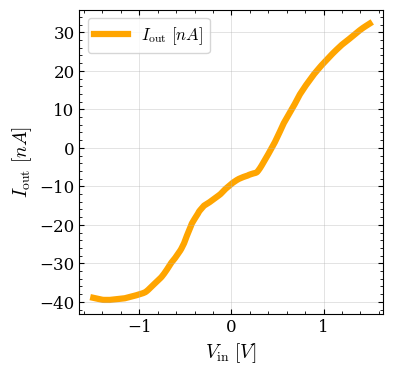

In [3]:
input_idx = 0
min_v = -1.5
max_v = 1.5
N = 500

v_step = float((max_v - min_v) / (N - 1))
print(v_step)
np.random.seed(402)
c_volts = torch.from_numpy(np.random.uniform(min_v, max_v, 6)).expand(N, -1).type(torch.float32)
c_v_left, c_v_right = c_volts[:, :input_idx], c_volts[:, input_idx:]

input_range = torch.linspace(min_v, max_v, N).unsqueeze(1)
input_tensor = torch.cat([c_v_left, input_range, c_v_right], dim=1)
input_tensor = input_tensor.to(device)

model.eval()
with torch.no_grad():
    I_out = model(input_tensor).detach().cpu().numpy().squeeze()

wl = 51#51
po = 3#3
I_smooth = savgol_filter(x=I_out, window_length=wl, polyorder=po, delta=v_step, mode='interp')
I_deriv = savgol_filter(x=I_out, window_length=wl, polyorder=po, deriv=1, delta=v_step, mode='interp')

plotting_range = torch.linspace(min_v, max_v, N)

fig, ax = plt.subplots(figsize=(4,4))
ax.set_position([0.22, 0.12, 0.76, 0.83])
ax.minorticks_on()
ax.tick_params(which='both', direction='in')
ax.tick_params(top=True, right=True, which='both')
#ax.plot(plotting_range, I_smooth, lw=1.2, zorder=2, label=r'$\mathrm{SavGol}[I_{\mathrm{out}}] \, \, [nA]$', ls='dashed', color='red')
#ax.plot(plotting_range, I_deriv, c='k', ls='dashdot', label=r'$\mathrm{SavGol}[I_{\mathrm{out}}] / dV_{\mathrm{in}} \, \, [nA / V]$')
ax.plot(plotting_range, I_out, lw=4.5, zorder=1, label=r'$I_{\mathrm{out}} \, \, [nA]$', c='orange')
ax.set_xlabel(r'$V_{\mathrm{in}} \, \, [V]$')
ax.set_ylabel(r'$I_{\mathrm{out}} \, \, [nA]$')
ax.grid(which='major', lw=0.5, alpha=0.5)#ax.grid(which='minor', lw=0.1, alpha=0.5)

#ax.axhline(y=0.0, lw=1.5, ls='--', alpha=1, c='k', zorder=-1)
#ax.hlines(y=0.01, xmin=0.3, xmax=-1.5, color='k')
arrow = ps.FancyArrowPatch(
    (-1.6, 0.01), (0.4, 0.01),
    arrowstyle="<->", mutation_scale=12,
    linewidth=1.5, color="k"
)
#ax.text(x=-0.8, y=0.25, s=r'NDR', fontweight='bold')
#ax.add_patch(arrow)
ax.tick_params(direction='in')
ax.set_box_aspect(1)

plt.legend()
#plt.savefig('iv_and_derivative_from_savgol.pdf', bbox_inches=None, pad_inches=None)
#plt.savefig('iv_for_savgol.pdf', bbox_inches=None, pad_inches=None)
plt.show()

tensor([0., 0., 0., 0., 0.])


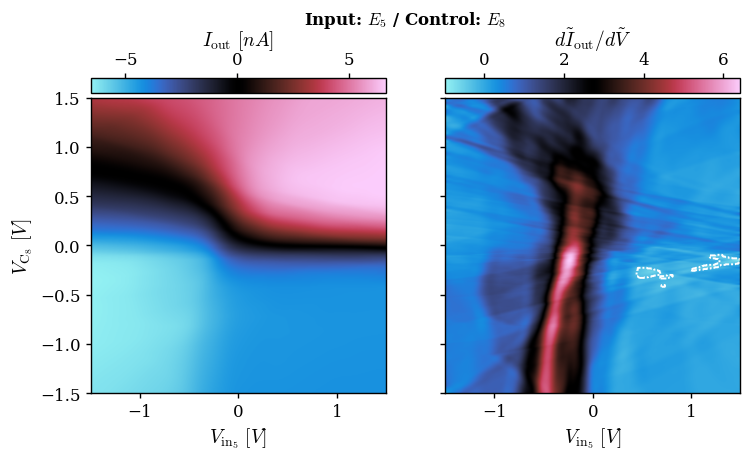

=== NDR comparison metrics ===
thr_norm: 0.25
NDR area fraction: 0.0055
min normalized slope: -0.9686
NDR strength (mean excess below -thr): 0.0007


In [74]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors

# optional: morphological cleanup (recommended)
try:
    from scipy.ndimage import binary_opening, binary_closing, label
    HAVE_MORPH = True
except Exception:
    HAVE_MORPH = False

# --- your settings ---
c_sweep_index = 6
input_idx = 3
in_features = 7

random_controls_on = False

N = 500
input_range = torch.linspace(min_v, max_v, N)
c_sweep_range = torch.linspace(min_v, max_v, N)
dx = float((max_v - min_v) / (N - 1))

#np.random.seed()
torch.manual_seed(84)
if random_controls_on:
    other_controls = (max_v - min_v)*torch.rand(size=(5,)) - min_v  # or random if you want
else: 
    other_controls = torch.zeros(5)  # or random if you want

print(other_controls)
window_length = 51
poly_order = 3

# --- model eval ---
model.eval()

# columns for other controls
other_control_cols = [k for k in range(in_features) if k not in (c_sweep_index, input_idx)]
assert len(other_control_cols) == len(other_controls), "other_controls length must match remaining input dims"

# --- collect outputs ---
raw_output = []     # list of arrays shape (Npts,)
I_lines = []        # smoothed I for left heatmap
grad_list = []      # dI/dV
for c_v in c_sweep_range:
    input_tensor = torch.empty(N, in_features, dtype=torch.float32)
    input_tensor[:, c_sweep_index] = c_v
    for l, other_c_v in zip(other_control_cols, other_controls):
        input_tensor[:, l] = other_c_v
    input_tensor[:, input_idx] = input_range

    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().squeeze().numpy()

    y_out = y_out

    # smooth I for plotting
    I_smooth = savgol_filter(y_out, window_length=window_length, polyorder=poly_order, mode='interp')
    I_lines.append(I_smooth)
    raw_output.append(y_out)

    # derivative (SG polynomial derivative)
    dIdV = savgol_filter(y_out, window_length=window_length, polyorder=poly_order,
                         deriv=1, delta=dx, mode='interp')
    grad_list.append(dIdV)

# stack into matrices: (Nlines, Npts) where Nlines == len(c_sweep_range) == N
c_i_mat = np.stack(I_lines, axis=0)
I_raw   = np.stack(raw_output, axis=0)
grad    = np.stack(grad_list, axis=0)

# --- percentile-based normalization for comparable slopes ---
# robust I-range per line (over Vin)
p_lo, p_hi = 5, 95
I_lo = np.percentile(I_raw, p_lo, axis=1, keepdims=True)#I_raw.min()
I_hi = np.percentile(I_raw, p_hi, axis=1, keepdims=True)#I_raw.max()

#I_lo = I_raw.min(axis=1, keepdims=True)
#I_hi = I_raw.max(axis=1, keepdims=True)

dI   = (I_hi - I_lo) + 1e-12  # avoid divide-by-zero

Vspan = float(input_range[-1] - input_range[0]) + 1e-12
g_norm = grad / (dI / Vspan)  # dimensionless slope

# --- NDR threshold in dimensionless units ---
# threshold is now comparable across devices

thr_norm = 0.25 #/ float(input_range[-1] - input_range[0])   # try 0.2–0.5; larger => stricter NDR definition

neg_mask = g_norm < -thr_norm

# --- optional: clean mask (remove tiny islands / speckle) ---
if HAVE_MORPH:
    neg_mask = binary_opening(neg_mask, structure=np.ones((3, 3)))
    neg_mask = binary_closing(neg_mask, structure=np.ones((5, 5)))

    # optional: keep only largest connected component (if you expect one blob)
    # lab, n = label(neg_mask)
    # if n > 0:
    #     sizes = np.bincount(lab.ravel())
    #     sizes[0] = 0
    #     neg_mask = lab == sizes.argmax()

# --- plot ---
# choose cmap
try:
    import cmasher as cmr
    cmap = plt.get_cmap('cmr.redshift')
except Exception:
    cmap = plt.get_cmap('plasma')

# center colormap at 0 for normalized slope
gmin = np.nanmin(g_norm)
gmax = np.nanmax(g_norm)
if gmin < 0 < gmax:
    norm = mcolors.TwoSlopeNorm(vmin=gmin, vcenter=0.0, vmax=gmax)
else:
    norm = None

latex_lw = 404.02908
in_inch = latex_lw / 72.27
scale = 1.5

fig, ax = plt.subplots(ncols=2, figsize=(scale*in_inch, scale*in_inch))
fig.subplots_adjust(top=0.9, bottom=0.08)

for a in ax:
    a.spines[:].set_linewidth(1.)
    a.tick_params(width=1.)

extent = [float(input_range[0]), float(input_range[-1]),
          float(c_sweep_range[0]), float(c_sweep_range[-1])]

im_0 = ax[0].imshow(c_i_mat, origin='lower', extent=extent, cmap=cmap)
im_1 = ax[1].imshow(g_norm, origin='lower', extent=extent, cmap=cmap)#, norm=norm)

# colorbar 0 (I)
divider_0 = make_axes_locatable(ax[0])
cax_0 = divider_0.append_axes('top', size='5%', pad=0.05)
cb_0 = fig.colorbar(im_0, cax=cax_0, orientation='horizontal')
cb_0.ax.xaxis.set_ticks_position('top')
cb_0.ax.xaxis.set_label_position('top')
cb_0.outline.set_linewidth(1.)
cb_0.ax.xaxis.set_tick_params(width=1.)
cb_0.set_label(label=r'$I_{\mathrm{out}} \, \, [nA]$')

# colorbar 1 (normalized slope)
divider_1 = make_axes_locatable(ax[1])
cax_1 = divider_1.append_axes('top', size='5%', pad=0.05)
cb_1 = fig.colorbar(im_1, cax=cax_1, orientation='horizontal')
cb_1.ax.xaxis.set_ticks_position('top')
cb_1.ax.xaxis.set_label_position('top')
cb_1.outline.set_linewidth(1.)
cb_1.ax.xaxis.set_tick_params(width=1.)
cb_1.set_label(label=r'$d\tilde{I}_{\mathrm{out}}/d\tilde{V}$') #\, / \, A_0/R_{\mathrm{in}}$')

# contour outline for NDR region
cs = ax[1].contour(neg_mask.astype(float), levels=[0.5], colors='w',
                   linewidths=1.4, linestyles=[(0, (3, 1, 1, 1))], extent=extent)

ax[0].set_xlabel(fr'$V_{{\mathrm{{in_{{{input_idx+2}}}}}}} \, \, [V]$')
ax[0].set_ylabel(fr'$V_{{\mathrm{{C_{{{c_sweep_index+2}}}}}}} \, \, [V]$')

ax[1].set_xlabel(fr'$V_{{\mathrm{{in_{{{input_idx+2}}}}}}} \, \, [V]$')
ax[1].tick_params(labelleft=False)

fig.suptitle(f'Input: $E_{input_idx+2}$ / Control: $E_{c_sweep_index+2}$', y=0.76, fontweight='bold', fontsize=12)

#plt.savefig(f'data_typ={data_type}_ndr_regions_c={c_sweep_index}_in={input_idx}_random_cntrls={random_controls_on}.pdf', bbox_inches='tight')
plt.show()

# --- comparison metrics you can log per device ---
# 1) NDR area fraction (what % of the (c,V) plane is NDR)
ndr_area_frac = float(np.mean(neg_mask))

# 2) most negative normalized slope (how steep)
min_g_norm = float(np.min(g_norm))

# 3) integrated NDR "strength" (dimensionless)
# sum of (-g_norm) where negative beyond threshold, times normalized area element
# (area element here is just dx*dc; if you want dimensionless, keep it as mean)
ndr_strength = float(np.mean(np.clip(-(g_norm + thr_norm), 0, None)))

print("=== NDR comparison metrics ===")
print(f"thr_norm: {thr_norm}")
print(f"NDR area fraction: {ndr_area_frac:.4f}")
print(f"min normalized slope: {min_g_norm:.4f}")
print(f"NDR strength (mean excess below -thr): {ndr_strength:.4f}")

## Statistical Distributions of NDR Metrics

In [5]:
import numpy as np
import torch
import pandas as pd
from scipy.signal import savgol_filter

# optional: morphological cleanup
try:
    from scipy.ndimage import binary_opening, binary_closing
    HAVE_MORPH = True
except Exception:
    HAVE_MORPH = False

def _lhs_sample(n: int, d: int, seed: int = 0) -> np.ndarray:
    """
    Simple Latin Hypercube Sampling in [0,1]^d.
    """
    rng = np.random.default_rng(seed)
    cut = np.linspace(0, 1, n + 1)
    u = rng.random((n, d))
    a = cut[:n]
    b = cut[1:n + 1]
    rdpoints = u * (b - a)[:, None] + a[:, None]     # (n,1) broadcast -> (n,d)
    H = np.zeros_like(rdpoints)
    for j in range(d):
        order = rng.permutation(n)
        H[:, j] = rdpoints[order, j]
    return H


def sample_ndr_metrics_across_controls(
    model,
    device,
    *,
    min_v: float,
    max_v: float,
    in_features: int = 7,
    input_idx: int = 3,           # Vin column index
    c_sweep_index: int = 6,        # which control voltage is swept (y-axis in your plot)
    N_vin: int = 100,
    N_c: int = 100,
    K: int = 200,                 # number of control-space samples for the *other* controls
    sampler: str = "sobol",       # "sobol" | "lhs" | "random"
    seed: int = 84,
    window_length: int = 51,
    poly_order: int = 3,
    thr_norm: float = 0.25,
    p_lo: float = 5,
    p_hi: float = 95,
    morph_open: bool = True,
    morph_close: bool = True,
    batch_rows: int = 65536       # chunk size for model inference (avoid GPU/CPU RAM spikes)
):
    """
    Samples the remaining control voltages (all except Vin and the swept control),
    runs the (V_C sweep) x (V_in sweep) grid for each sample, and returns a DataFrame
    with NDR metrics.

    Metrics per sample match your plot code:
      - ndr_area_frac = mean(neg_mask) over the 2D grid
      - min_g_norm    = min of normalized slope over the 2D grid
      - ndr_strength  = mean excess below -thr_norm: mean( clip(-(g_norm + thr_norm), 0, inf) )

    Returns:
      df: pandas DataFrame with sampled control values + metrics
    """

    # --- grids ---
    Vin = torch.linspace(min_v, max_v, N_vin)
    Vc  = torch.linspace(min_v, max_v, N_c)
    dx = float((max_v - min_v) / (N_vin - 1))
    Vspan = float(Vin[-1] - Vin[0]) + 1e-12

    # columns for other (non-swept) controls
    other_control_cols = [k for k in range(in_features) if k not in (c_sweep_index, input_idx)]
    D = len(other_control_cols)  # number of "other" controls we sample (should be 5 in your setup)

    # --- sample other controls in [min_v,max_v]^D ---
    sampler = sampler.lower()
    if sampler == "sobol":
        engine = torch.quasirandom.SobolEngine(dimension=D, scramble=True, seed=seed)
        U = engine.draw(K).cpu().numpy()  # (K,D) in [0,1]
    elif sampler == "lhs":
        U = _lhs_sample(K, D, seed=seed)
    elif sampler == "random":
        rng = np.random.default_rng(seed)
        U = rng.random((K, D))
    else:
        raise ValueError("sampler must be one of: 'sobol', 'lhs', 'random'")

    other_controls_samples = min_v + (max_v - min_v) * U  # (K,D)

    # --- inference helper (chunked) ---
    def _model_predict(x: torch.Tensor) -> np.ndarray:
        model.eval()
        out_chunks = []
        with torch.no_grad():
            for i in range(0, x.shape[0], batch_rows):
                xb = x[i:i+batch_rows].to(device)
                yb = model(xb).detach().cpu().squeeze().numpy()
                out_chunks.append(yb)
        return np.concatenate(out_chunks, axis=0)

    # --- compute metrics for one sampled other-controls vector ---
    def _metrics_for_other_controls(other_vals: np.ndarray):
        # build I_raw (N_c, N_vin) and grad (N_c, N_vin)
        I_raw = np.empty((N_c, N_vin), dtype=np.float64)
        grad  = np.empty((N_c, N_vin), dtype=np.float64)

        # build each Vc line
        for i, c_v in enumerate(Vc):
            x = torch.empty((N_vin, in_features), dtype=torch.float32)
            x[:, input_idx] = Vin
            x[:, c_sweep_index] = c_v

            for col, val in zip(other_control_cols, other_vals):
                x[:, col] = float(val)

            y = _model_predict(x)

            I_raw[i, :] = y
            grad[i, :] = savgol_filter(
                y,
                window_length=window_length,
                polyorder=poly_order,
                deriv=1,
                delta=dx,
                mode="interp"
            )

        # robust per-line I-range for normalization
        I_lo = np.percentile(I_raw, p_lo, axis=1, keepdims=True)
        I_hi = np.percentile(I_raw, p_hi, axis=1, keepdims=True)
        dI = (I_hi - I_lo) + 1e-12

        # dimensionless normalized slope
        g_norm = grad / (dI / Vspan)

        # NDR mask
        neg_mask = g_norm < -thr_norm

        # optional morphology
        if HAVE_MORPH:
            if morph_open:
                neg_mask = binary_opening(neg_mask, structure=np.ones((3, 3)))
            if morph_close:
                neg_mask = binary_closing(neg_mask, structure=np.ones((5, 5)))

        # metrics
        ndr_area_frac = float(np.mean(neg_mask))
        min_g_norm = float(np.min(g_norm))
        ndr_strength = float(np.mean(np.clip(-(g_norm + thr_norm), 0, None)))

        return ndr_area_frac, min_g_norm, ndr_strength

    # --- run all samples ---
    rows = []
    for k in range(K):
        other_vals = other_controls_samples[k]
        area_frac, min_slope, strength = _metrics_for_other_controls(other_vals)

        row = {f"V_other_{col}": float(val) for col, val in zip(other_control_cols, other_vals)}
        row.update({
            "ndr_area_frac": area_frac,
            "min_g_norm": min_slope,
            "ndr_strength": strength,
        })
        rows.append(row)

    df = pd.DataFrame(rows)
    return df


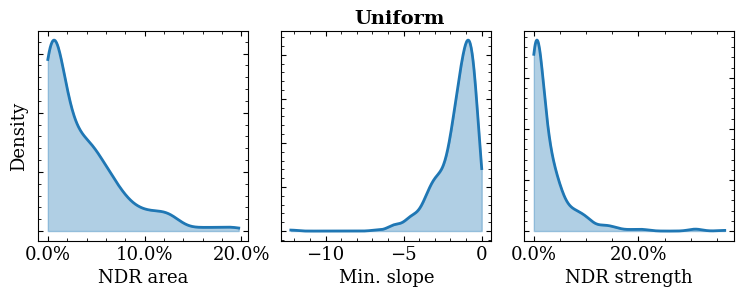

In [69]:
data_type = 'uni_1e7'
input_idx = 3
c_sweep_idx = 0

state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model = model.to(device)
res = 100
df = sample_ndr_metrics_across_controls(
    model, device,
    min_v=min_v, max_v=max_v,
    in_features=7,
    input_idx=input_idx,
    c_sweep_index=c_sweep_idx,
    N_vin=res,     # tip: reduce for statistics
    N_c=res,       # tip: reduce for statistics
    K=500,         # number of random “other-control” settings
    sampler="lhs",
    seed=84,
    window_length=51,
    poly_order=3,
    thr_norm=0.25
)

#print(df.describe())

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.ticker import PercentFormatter

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 13,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 13,    # affects horizontal colorbar ticks
    "ytick.labelsize": 13,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "legend.fontsize": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

def kde_fill(ax, x, bw=None, n=400, alpha=0.35):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    kde = gaussian_kde(x, bw_method=bw)
    xs = np.linspace(x.min(), x.max(), n)
    ys = kde(xs)

    line, = ax.plot(xs, ys, linewidth=2.0)
    ax.fill_between(xs, 0, ys, alpha=alpha, color=line.get_color())

def aligned_triptych(figsize=(9, 3),
                     left=0.08, bottom=0.22,
                     w=0.27, h=0.70,
                     gap=0.00):
    fig = plt.figure(figsize=figsize)

    ax0 = fig.add_axes([left + 0*(w+gap), bottom, w, h])
    ax1 = fig.add_axes([left + 1*(w+gap), bottom, w, h])
    ax2 = fig.add_axes([left + 2*(w+gap), bottom, w, h])

    return fig, (ax0, ax1, ax2)

fig, ax  = aligned_triptych()

for a in ax:
    a.set_box_aspect(1)
    a.minorticks_on()
    a.tick_params(top=True, right=True, which='both')
    a.tick_params(labelleft=False)
    a.tick_params(direction='in', which='both')

kde_fill(ax[0], df["ndr_area_frac"])
ax[0].set_xlabel("NDR area")
ax[0].set_ylabel('Density')
ax[0].xaxis.set_major_formatter(PercentFormatter(1))
#ax[0].set_ylabel("count")

kde_fill(ax[1], df["min_g_norm"])
ax[1].set_xlabel("Min. slope")
#ax[1].set_ylabel("count")

kde_fill(ax[2], df["ndr_strength"])
ax[2].set_xlabel("NDR strength")
ax[2].xaxis.set_major_formatter(PercentFormatter(1))
#ax[2].set_ylabel("count")

if data_type == 'uni_1e7':
    fig.suptitle(t='Uniform', fontweight='bold', fontsize=14, y=0.99)
elif data_type == 'data_vMB_ring_1e7':
    fig.suptitle(t='Annular', fontweight='bold', fontsize=14, y=0.99)
elif data_type == 'grad_towards_1e7':
    fig.suptitle(t='Gradient towards the output', fontweight='bold', fontsize=14, y=0.99)
elif data_type == 'grad_away_1e7':
    fig.suptitle(t='Gradient away from the output', fontweight='bold', fontsize=14, y=0.99)
plt.savefig(f'data_type={data_type}_ndr_metrics_statistics_in={input_idx}_c_sweep={c_sweep_idx}.pdf')

plt.show()

tensor([[-1.5000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [-1.4697,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [-1.4394,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [-1.4091,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [-1.3788,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]],
       device='cuda:0')


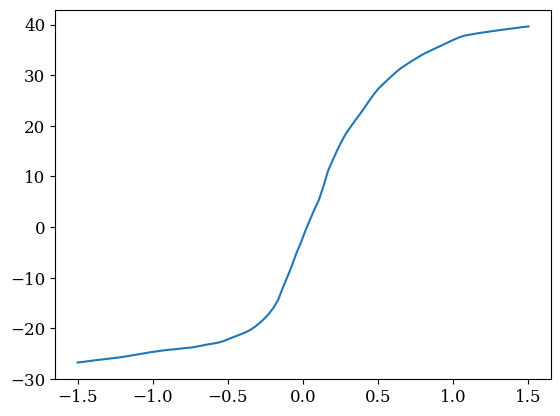

In [45]:
model.eval()

c_volt = 0.0
c_tensor = torch.linspace(c_volt, c_volt, 100).unsqueeze(0)

in_range = torch.linspace(-1.5, 1.5, 100).unsqueeze(0)
input_tensor = torch.zeros(100, in_features)
input_tensor[:, input_idx] = in_range
input_tensor[:, c_sweep_index] = c_volt
input_tensor = input_tensor.to(device)
print(input_tensor[:5, :])
with torch.no_grad():
    I_out = model(input_tensor).detach().cpu().squeeze()

plt.plot(in_range.squeeze(), I_out)

tensor([0., 0., 0., 0., 0.])


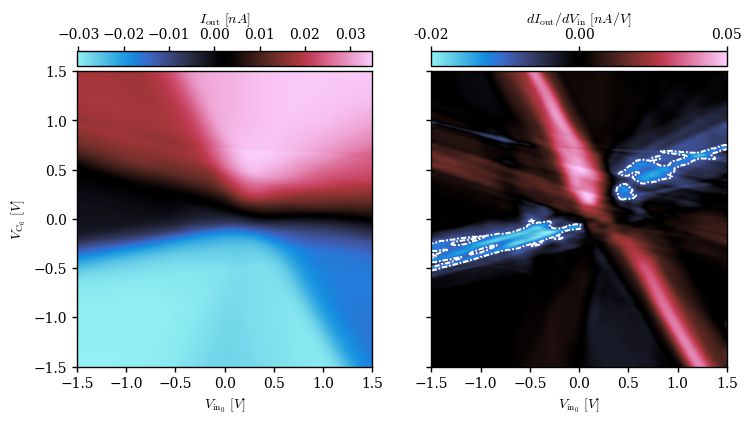

In [50]:
"""c_sweep_index = 6
input_idx = 0

in_features = 7

N = 500
input_range = torch.linspace(min_v, max_v, N)
c_sweep_range = torch.linspace(min_v, max_v, N)
dx = float((max_v - min_v) / (N - 1))

np.random.seed()
other_controls = torch.zeros(5)#torch.tensor(np.random.uniform(min_v, max_v, 5)).type(torch.float32)
print(other_controls)
window_length = 51
poly_order = 3

I_lines = []
raw_output = []
model.eval()
other_control_cols = []
for k in range(in_features):
    if k not in (c_sweep_index, input_idx):
        other_control_cols.append(k)        

for c_v in c_sweep_range:
    input_tensor = torch.empty(N, 7, dtype=torch.float32)
    input_tensor[:, c_sweep_index] = c_v
    for l, other_c_v in zip(other_control_cols, other_controls):
        input_tensor[:, l] = other_c_v
    input_tensor[:, input_idx] = input_range
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().squeeze().numpy()
    I_smooth = savgol_filter(x=y_out, window_length=window_length, polyorder=poly_order, delta=dx, mode='interp')
    I_lines.append(I_smooth)
    raw_output.append(y_out)
    
c_i_mat = np.stack(I_lines)

grad_list = []
for line in raw_output:
    #dIdV = np.gradient(line, dx)
    dIdV = savgol_filter(x=line, window_length=window_length, polyorder=poly_order, deriv=1, delta=dx, mode='interp')
    grad_list.append(dIdV)
grad = np.stack(grad_list)    

cmap = cmr.rainforest
cmap = plt.get_cmap('cmr.redshift')
#cmap = plt.get_cmap('plasma')

g_min = np.nanmin(grad)
g_max = np.nanmax(grad)

if g_min < 0 < g_max:
    norm = mcolors.TwoSlopeNorm(vmin=g_min, vcenter=0.0, vmax=g_max)
else:
    norm = None

latex_lw = 404.02908
in_inch = latex_lw / 72.27

scale=1.5
fig, ax = plt.subplots(ncols=2, figsize=(scale*in_inch, scale*in_inch))
fig.subplots_adjust(top=0.9, bottom=0.08)

ax[0].spines[:].set_linewidth(1.)
ax[1].spines[:].set_linewidth(1.)

ax[0].tick_params(width=1.)
ax[1].tick_params(width=1.)

extent = [input_range[0], input_range[-1], c_sweep_range[0], c_sweep_range[-1]]
im_0 = ax[0].imshow(c_i_mat, origin='lower', extent=extent, cmap=cmap)
im_1 = ax[1].imshow(grad, origin='lower', extent=extent, cmap=cmap, norm=norm)

divider_0 = make_axes_locatable(ax[0])
cax_0 = divider_0.append_axes('top', size='5%', pad=0.05)
cb_0 = fig.colorbar(im_0, cax=cax_0, orientation='horizontal')
cb_0.ax.xaxis.set_ticks_position('top')
cb_0.ax.xaxis.set_label_position('top')
cb_0.outline.set_linewidth(1.)
cb_0.ax.xaxis.set_tick_params(width=1.)
cb_0.set_label(label=r'$I_{\mathrm{out}} \, \, [nA]$')

divider_1 = make_axes_locatable(ax[1])
cax_1 = divider_1.append_axes('top', size='5%', pad=0.05)
#ticks = np.linspace(grad.min(), grad.max(), 3)
ticks = [grad.min(), 0.0, grad.max()]
cb_1 = fig.colorbar(im_1, cax=cax_1, orientation='horizontal')
cb_1.ax.xaxis.set_ticks_position('top')
cb_1.ax.xaxis.set_label_position('top')
cb_1.outline.set_linewidth(1.)
cb_1.ax.xaxis.set_tick_params(width=1.)
cb_1.set_label(label=r'$dI_{\mathrm{out}} / dV_{\mathrm{in}}  \, \, [nA/V]$')
cb_1.set_ticks(ticks)
cb_1.ax.set_xticklabels([f'{t:.2f}' for t in ticks])

eps = 1e-9
neg_mask = grad < -1e-2
#print(neg_mask.mean())
cs = ax[1].contour(neg_mask.astype(float), levels=[0.5], colors='w', linewidths=1.4, linestyles=[(0, (3, 1, 1, 1))], extent=extent)

ax[0].set_xlabel(fr'$V_{{\mathrm{{in_{{{input_idx}}}}}}} \, \, [V]$')
ax[0].set_ylabel(fr'$V_{{\mathrm{{C_{{{c_sweep_index}}}}}}} \, \, [V]$')

ax[1].set_xlabel(fr'$V_{{\mathrm{{in_{{{input_idx}}}}}}} \, \, [V]$')
ax[1].tick_params(labelleft=False)

plt.savefig(f'data_typ={data_type}_ndr_regions_c={c_sweep_index}_in={input_idx}.pdf', bbox_inches='tight')
plt.show()"""

In [41]:
def ndr_regions(model, c_sweep_idx, in_sweep_idx, other_controls, min_v=-1.5, max_v=1.5, resolution=500, window_length=51, poly_order=3):

    model.eval()
    
    in_features = model.layer_dims[0]
    dx = float((max_v - min_v) / (resolution - 1))
    
    I_lines = []
    raw_output = []
    other_control_cols = []

    c_sweep_range = torch.linspace(min_v, max_v, resolution)
    in_sweep_range = torch.linspace(min_v, max_v, resolution)
    
    for k in range(in_features):
        if k not in (c_sweep_idx, in_sweep_idx):
            other_control_cols.append(k)

    for c_v in c_sweep_range:
        input_tensor = torch.empty(resolution, in_features, dtype=torch.float32)
        input_tensor[:, c_sweep_idx] = c_v
        for l, other_c_v in zip(other_control_cols, other_controls):
            input_tensor[:, l] = other_c_v
        input_tensor[:, in_sweep_idx] = in_sweep_range
        input_tensor = input_tensor.to(device)
        with torch.no_grad():
            y_out = model(input_tensor).detach().cpu().squeeze().numpy()
        I_smooth = savgol_filter(x=y_out, window_length=window_length, polyorder=poly_order, delta=dx, mode='interp')
        I_lines.append(I_smooth)
        raw_output.append(y_out)
        
    I_ij = np.stack(I_lines)

    grad_list = []
    
    for line in raw_output:
        dIdV = savgol_filter(x=line, window_length=window_length, polyorder=poly_order, deriv=1, delta=dx, mode='interp')
        grad_list.append(dIdV)
    grad_ij = np.stack(grad_list)    

    out_dict = {'I_ij': I_ij, 'grad_ij': grad_ij}

    return out_dict

def ndr_statistics(num_samples, neg_threshold, model, c_sweep_idx, in_sweep_idx, min_v=-1.5, max_v=1.5, resolution=500, window_length=51, poly_order=3):

    ndr_area_list = []
    peak_strength_list = []
    avg_negativity_list = []
    
    for _ in range(num_samples):

        other_controls = torch.tensor(np.random.uniform(min_v, max_v, 5)).type(torch.float32)
        out = ndr_regions(model=model, c_sweep_idx=c_sweep_idx, in_sweep_idx=in_sweep_idx, other_controls=other_controls, min_v=min_v, max_v=max_v, resolution=resolution, window_length=window_length, poly_order=poly_order)
        
        neg_mask = out['grad_ij'] < -neg_threshold
        ndr_area_list.append(neg_mask.mean())

        min_peak = out['grad_ij'].min()
        max_peak = out['grad_ij'].max()

        peak_strength = np.abs(min_peak) / (np.abs(max_peak) + 1e-12)
        
        peak_strength_list.append(peak_strength)

        neg_vals = out['grad_ij'][out['grad_ij'] < 0.0]

        if neg_vals.size > 0:
            avg_negativity_list.append(neg_vals.mean())
        if neg_vals.size == 0:
            avg_negativity_list.append(0.0)

    ndr_area_avg = np.array(ndr_area_list).mean()
    peak_strength_avg = np.array(peak_strength_list).mean()
    avg_negativity_avg = np.array(avg_negativity_list).mean()

    ndr_stats_dict = {
        'ndr_area_samples': ndr_area_list,
        'peak_strength_samples': peak_strength_list,
        'avg_negativity_samples': avg_negativity_list
    }

    return ndr_stats_dict

In [42]:
stats = ndr_statistics(num_samples=100, neg_threshold=0.001, model=model, c_sweep_idx=1, in_sweep_idx=0, min_v=-1.5, max_v=1.5, resolution=100, window_length=51, poly_order=3)

print(np.mean(stats['ndr_area_samples']) * 100)
print(np.mean(stats['peak_strength_samples']))
print(np.mean(stats['avg_negativity_samples']))

26.719099999999997
1.0426841
-0.12792152


In [53]:
state_dict = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_radial_n_a=200.pth', weights_only=False, map_location='cpu')
args = state_dict['args']

model = NeuralNet(args['layer_dims'], args['x_mean'], args['x_std'], args['y_mean'], args['y_std'], batch_norm=True)
model.load_state_dict(state_dict['model_state_dict'])

model = model.to(device)

controls = [1, 2, 3, 4, 5, 6]

area_mean = []
peak_mean = []
negativity_mean = []

area_std = []
peak_std = []
negativity_std = []

for c_idx in controls:

    stats = ndr_statistics(num_samples=200, neg_threshold=0.01, model=model, c_sweep_idx=c_idx, in_sweep_idx=0, min_v=-1.5, max_v=1.5, resolution=100, window_length=51, poly_order=3)
    ndr_areas_samples = np.array(stats['ndr_area_samples'])
    peak_strength_samples = np.array(stats['peak_strength_samples'])
    avg_negativity_samples = np.array(stats['avg_negativity_samples'])
    
    area_mean.append(ndr_areas_samples.mean())
    area_std.append(ndr_areas_samples.std())
    
    peak_mean.append(peak_strength_samples.mean())
    peak_std.append(peak_strength_samples.std())
    
    negativity_mean.append(avg_negativity_samples.mean())
    negativity_std.append(avg_negativity_samples.std())
    print(c_idx)

1
2
3
4
5
6


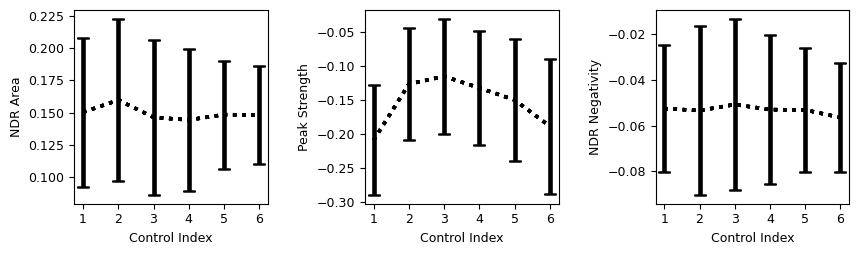

In [54]:
ncols = 3
fig, ax = plt.subplots(ncols=ncols, figsize=(10, 10))
fig.subplots_adjust(wspace=0.5)

for a in ax:
    a.set_box_aspect(1)
    a.set_xticks(np.arange(1, 7, 1))
    a.set_xlabel(r'Control Index')

for c_idx in controls:
    ax[0].errorbar(
        controls,
        area_mean,
        yerr=area_std,
        capsize=4,
        linewidth=2.5,
        ls='dotted',
        c='k'
    )
    ax[0].set_ylabel(f'NDR Area')

    ax[1].errorbar(
        controls,
        peak_mean,
        yerr=peak_std,
        capsize=4,
        linewidth=2.5,
        ls='dotted',
        c='k'
    ) 
    ax[1].set_ylabel(f'Peak Strength')

    ax[2].errorbar(
        controls,
        negativity_mean,
        yerr=negativity_std,
        capsize=4,
        linewidth=2.5,
        ls='dotted',
        c='k'
    )
    ax[2].set_ylabel(f'NDR Negativity')

plt.savefig(f'/home/hd/hd_hd/hd_gy283/kmc_project/plots/ndr_statistics_radial.pdf')